In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier

In [3]:
df_model = pd.read_csv("../data/interim/train_cleaned_v1.csv")

print("Shape:", df_model.shape)

df_model.head()

Shape: (149730, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
X = df_model.drop("SeriousDlqin2yrs", axis=1)
y = df_model["SeriousDlqin2yrs"]

print("X:", X.shape)
print("y:", y.shape)

X: (149730, 10)
y: (149730,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(119784, 10)
(29946, 10)


In [6]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative:", neg)
print("Positive:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative: 111881
Positive: 7903
scale_pos_weight: 14.156775907883082


In [7]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [8]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(y_pred_xgb[:10])
print(y_prob_xgb[:10])

[1 0 1 0 0 0 0 0 0 0]
[0.77109396 0.4781493  0.7914553  0.07603469 0.23549059 0.22813569
 0.23509149 0.34124765 0.21453172 0.42834526]


In [9]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_xgb))

Accuracy:
0.7970680558338342

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27970
           1       0.21      0.77      0.33      1976

    accuracy                           0.80     29946
   macro avg       0.60      0.78      0.61     29946
weighted avg       0.93      0.80      0.84     29946


Confusion Matrix:
[[22357  5613]
 [  464  1512]]

ROC-AUC:
0.8597090904222133


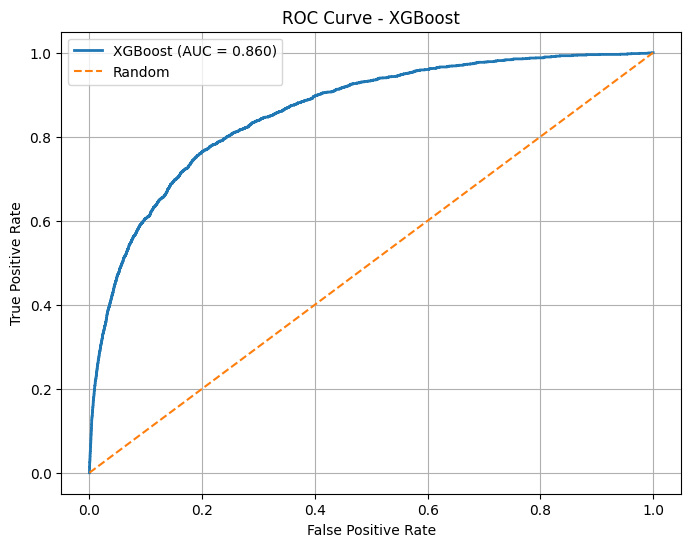

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

roc_auc = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'XGBoost (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")

plt.legend()
plt.grid(True)

plt.show()

In [11]:
import joblib

joblib.dump(
    xgb,
    "../models/xgboost_v1.pkl"
)

print("XGBoost model saved!")

XGBoost model saved!


In [12]:
import pandas as pd

model_results = {
    "Baseline LR": {
        "Accuracy": 0.938,
        "Precision": 0.620,
        "Recall": 0.140,
        "F1": 0.230,
        "ROC_AUC": 0.807
    },

    "Balanced LR": {
        "Accuracy": 0.858,
        "Precision": 0.258,
        "Recall": 0.611,
        "F1": 0.363,
        "ROC_AUC": 0.814
    },

    "SMOTE LR": {
        "Accuracy": 0.850,
        "Precision": 0.247,
        "Recall": 0.619,
        "F1": 0.353,
        "ROC_AUC": 0.812
    },

    "XGBoost": {
        "Accuracy": 0.797,
        "Precision": 0.212,
        "Recall": 0.765,
        "F1": 0.332,
        "ROC_AUC": 0.860
    }
}

results_df = pd.DataFrame(model_results).T

results_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Baseline LR,0.938,0.620,0.140,0.230,0.807
Balanced LR,0.858,0.258,0.611,0.363,0.814
SMOTE LR,0.850,0.247,0.619,0.353,0.812
XGBoost,0.797,0.212,0.765,0.332,0.860


In [13]:
results_df.to_csv(
    "../models/model_leaderboard.csv",
    index=True
)

print("Leaderboard updated and saved!")

Leaderboard updated and saved!


In [14]:
import joblib

joblib.dump(
    xgb,
    "../models/xgboost_v1.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5,0.6,0.7]

for threshold in thresholds:
    y_pred_thresh = (y_prob_xgb >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")


Threshold: 0.1
Precision: 0.082
Recall: 0.987
F1-score: 0.151

Threshold: 0.2
Precision: 0.115
Recall: 0.936
F1-score: 0.205

Threshold: 0.3
Precision: 0.143
Recall: 0.881
F1-score: 0.247

Threshold: 0.4
Precision: 0.173
Recall: 0.821
F1-score: 0.286

Threshold: 0.5
Precision: 0.212
Recall: 0.765
F1-score: 0.332

Threshold: 0.6
Precision: 0.263
Recall: 0.655
F1-score: 0.375

Threshold: 0.7
Precision: 0.337
Recall: 0.562
F1-score: 0.421


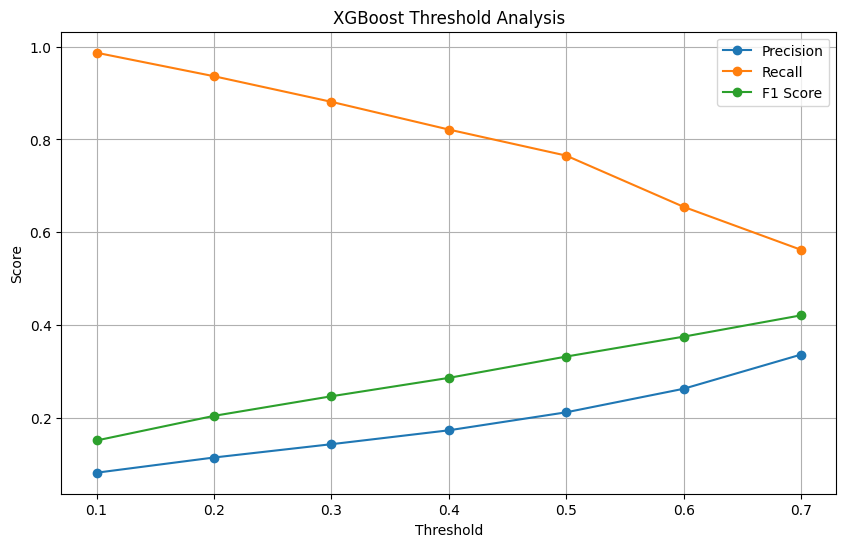

In [16]:
import matplotlib.pyplot as plt

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5,0.6,0.7]

precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred_thresh = (y_prob_xgb >= threshold).astype(int)

    precisions.append(
        precision_score(y_test, y_pred_thresh)
    )

    recalls.append(
        recall_score(y_test, y_pred_thresh)
    )

    f1_scores.append(
        f1_score(y_test, y_pred_thresh)
    )

plt.figure(figsize=(10,6))

plt.plot(
    thresholds,
    precisions,
    marker='o',
    label='Precision'
)

plt.plot(
    thresholds,
    recalls,
    marker='o',
    label='Recall'
)

plt.plot(
    thresholds,
    f1_scores,
    marker='o',
    label='F1 Score'
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Analysis")

plt.legend()
plt.grid(True)

plt.show()

In [17]:
import shap

In [18]:
explainer = shap.TreeExplainer(xgb)

print("SHAP Explainer Created!")

SHAP Explainer Created!


In [19]:
X_sample = X_test.iloc[:100]

shap_values = explainer.shap_values(X_sample)

print(np.array(shap_values).shape)

(100, 10)


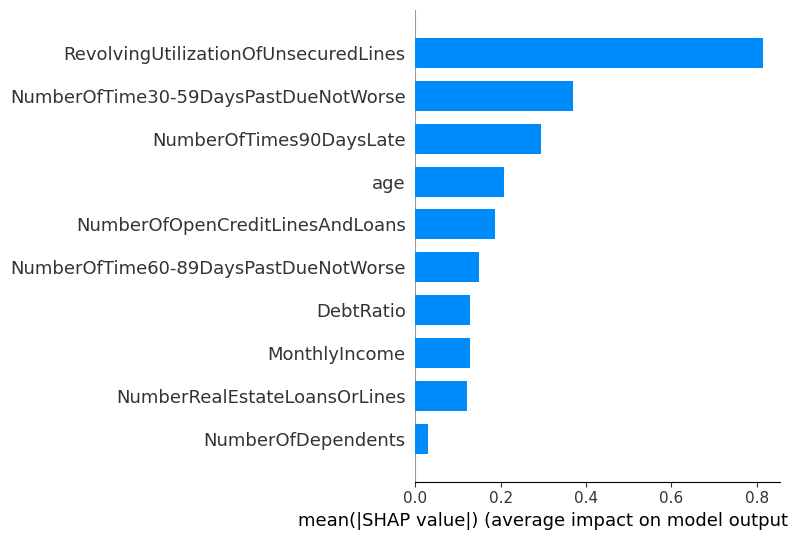

In [20]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

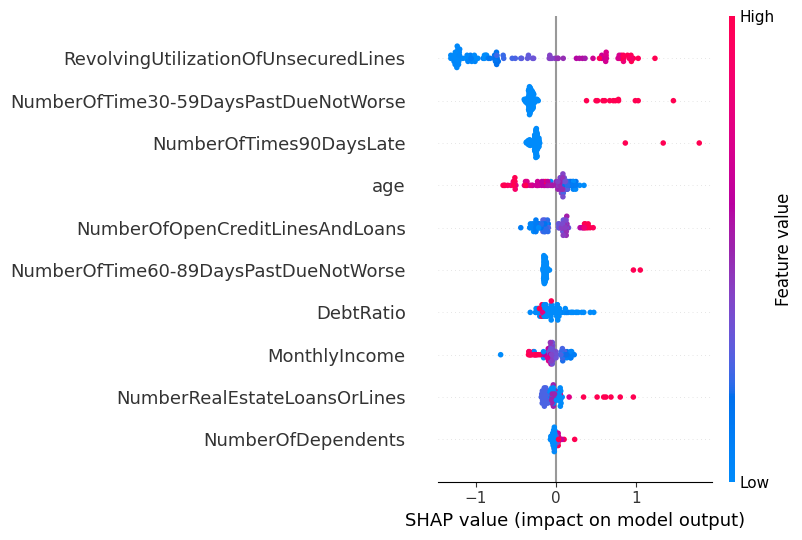

In [21]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [22]:
customer_index = 0

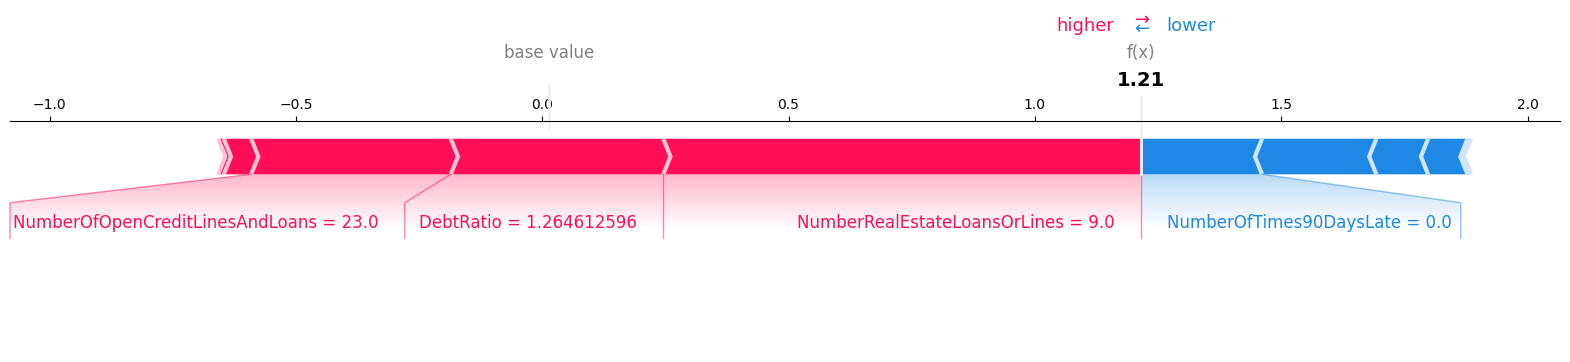

In [23]:
shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_sample.iloc[customer_index],
    matplotlib=True
)

In [24]:
print(X_train.columns.tolist())

['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
